# Exploratory Data Analysis

## Context

I previously explored and validated data from the Brazilian E-Commerce Public Dataset by Olist published on Kaggle, built an order-level dataset for a dashboard, and created a visualization in Tableau Public.

After looking at the dashboard data, my attention was drawn to the retention rate — the share of new customers stabilizes around 98%.

## Project goal

The goal of this analysis is to understand customer repeat purchase behavior and evaluate whether low retention is a temporary effect of a young marketplace or a structural characteristic of the business.

In order to do that, I will analyze the following points:

- Distribution of orders per customer
- Repeat order rate dynamics
- Time between repeat orders
- New vs repeat order comparison: AOV and freight share
- Item category comparison

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

In [2]:
orders = pd.read_csv('output/orders.csv')
total_GMV = orders['payment_value'].sum()
display(orders.info())
orders.head()

<class 'pandas.DataFrame'>
RangeIndex: 96477 entries, 0 to 96476
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       96477 non-null  str    
 1   customer_id    96477 non-null  str    
 2   order_date     96477 non-null  str    
 3   payment_value  96477 non-null  float64
 4   items_price    96477 non-null  float64
 5   freight_value  96477 non-null  float64
 6   order_num      96477 non-null  int64  
dtypes: float64(3), int64(1), str(3)
memory usage: 5.2 MB


None

,order_id,customer_id,order_date,payment_value,items_price,freight_value,order_num
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,2017-10-02,38.71,29.99,8.72,2
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,2018-07-24,141.46,118.70,22.76,1
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-08,179.12,159.90,19.22,1
3,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,2017-11-18,72.20,45.00,27.20,1
4,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-13,28.62,19.90,8.72,1


In [3]:
customers_order_cnt = orders.groupby('customer_id').agg({
    'order_id': 'count',
    'payment_value': 'sum'}) \
    .reset_index()
customers_order_cnt

,customer_id,order_id,payment_value
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19
2,0000f46a3911fa3c0805444483337064,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,1,196.89
...,...,...,...
93352,fffcf5a5ff07b0908bd4e2dbc735a684,1,2067.42
93353,fffea47cd6d3cc0a88bd621562a9d061,1,84.58
93354,ffff371b4d645b6ecea244b27531430a,1,112.46
93355,ffff5962728ec6157033ef9805bacc48,1,133.69


## Distribution of orders per customer

How many orders does each user make?

After drawing a histogram, I can see that:

- 97% of all users make only one order
- 2.8% make two orders
- 0.2% make more than two orders

Text(0.5, 0, 'Order count')

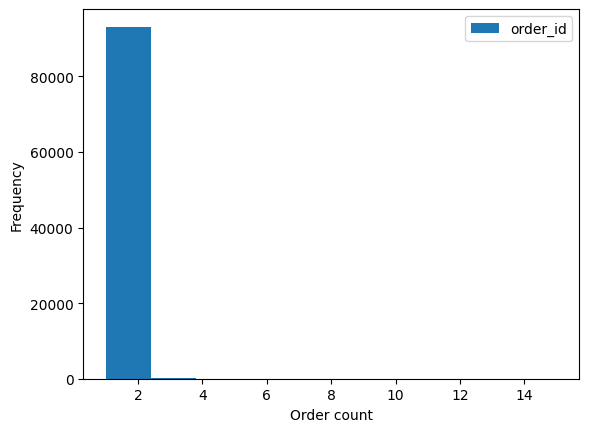

In [4]:
customers_order_cnt.plot.hist(column='order_id').set_xlabel('Order count')

In [5]:
# customers number by how many orders they made
customers_order_cnt.groupby('order_id')['customer_id'].count()

order_id
1     90556
2      2573
3       181
4        28
5         9
6         5
7         3
9         1
15        1
Name: customer_id, dtype: int64

In [6]:
# share of all customers
total_customers = customers_order_cnt['order_id'].count()
customers_order_cnt.groupby('order_id')['customer_id'].count() / total_customers * 100

order_id
1     96.999689
2      2.756087
3      0.193879
4      0.029992
5      0.009640
6      0.005356
7      0.003213
9      0.001071
15     0.001071
Name: customer_id, dtype: float64

## Repeat order rate

I'm going to check the dynamics of the repeat rate to see whether it was very low at the beginning, when new customers were just starting to come to the marketplace, and whether it improved over time.

The data shows that this is not the case. The repeat rate was lower in the beginning, but it quickly stabilizes at around 3% over time.

In [7]:
orders['is_repeat'] = orders['order_num'] > 1
orders['order_month'] = orders['order_date'].apply(lambda d: d[:7])
orders

,order_id,customer_id,order_date,payment_value,items_price,freight_value,order_num,is_repeat,order_month
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,2017-10-02,38.71,29.99,8.72,2,True,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,2018-07-24,141.46,118.70,22.76,1,False,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-08,179.12,159.90,19.22,1,False,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,2017-11-18,72.20,45.00,27.20,1,False,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-13,28.62,19.90,8.72,1,False,2018-02
...,...,...,...,...,...,...,...,...,...
96472,9c5dedf39a927c1b2549525ed64a053c,6359f309b166b0196dbf7ad2ac62bb5a,2017-03-09,85.08,72.00,13.08,1,False,2017-03
96473,63943bddc261676b46f01ca7ac2f7bd8,da62f9e57a76d978d02ab5362c509660,2018-02-06,195.00,174.90,20.10,1,False,2018-02
96474,83c1379a015df1e13d02aae0204711ab,737520a9aad80b3fbbdad19b66b37b30,2017-08-27,271.01,205.99,65.02,1,False,2017-08
96475,11c177c8e97725db2631073c19f07b62,5097a5312c8b157bb7be58ae360ef43c,2018-01-08,441.16,359.98,81.18,1,False,2018-01


In [8]:
orders.groupby('order_month')['is_repeat'].mean() * 100

order_month
2016-10    1.132075
2016-12    0.000000
2017-01    4.400000
2017-02    1.512402
2017-03    1.688924
2017-04    2.040816
2017-05    2.679075
2017-06    3.125997
2017-07    3.099174
2017-08    3.243501
2017-09    3.518072
2017-10    3.349710
2017-11    3.141720
2017-12    3.174315
2018-01    3.211204
2018-02    4.073227
2018-03    3.270027
2018-04    3.177405
2018-05    3.600533
2018-06    3.623545
2018-07    3.409644
2018-08    3.259329
Name: is_repeat, dtype: float64

Text(0, 0.5, 'Repear orders rate %')

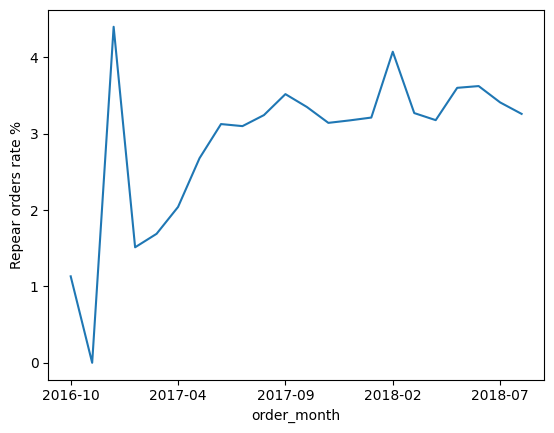

In [9]:
(orders.groupby('order_month')['is_repeat'].mean() * 100).plot().set_ylabel('Repear orders rate %')

## Days between orders

Since Olist provided data for the first two years after the business launch, there might not have been enough time for users to make repeat orders. To check this assumption, I look at how much time it usually takes customers to place a second order.

The data shows that, on average, customers with multiple purchases take 79 days to place the next order. The median time is 29 days.

Looking at these values over time with monthly aggregation shows that the average and median time to the next order increase over time, which is logical, considering that orders could not have been made before the launch of the marketplace.

This suggests that two years is a sufficient time span to observe repeat purchases, yet the marketplace still shows only a ~3% repeat order rate.

min         0.000000
max       609.000000
mean       79.147436
median     29.000000
Name: days_to_prev_order, dtype: float64

Text(0.5, 0, 'Days to previous order')

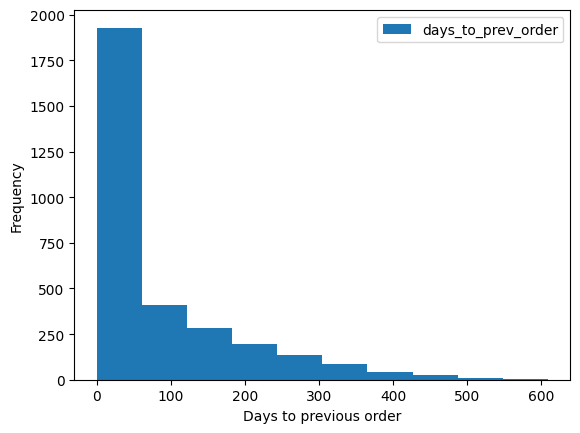

In [10]:
repeat_customers = customers_order_cnt[customers_order_cnt['order_id'] > 1]['customer_id']

repeat_cust_orders = orders.merge(repeat_customers, on='customer_id', how='inner') \
    .sort_values(by=['customer_id', 'order_date']) \
    .reset_index(drop=True)

def date_diff_row(row):
    if row.name > 0 and repeat_cust_orders['customer_id'].iloc[row.name - 1] == row['customer_id']:
        prev_date = datetime.strptime(repeat_cust_orders['order_date'].iloc[row.name - 1], "%Y-%m-%d")
        cur_date = datetime.strptime(row['order_date'], "%Y-%m-%d")
        return (cur_date - prev_date).days
    else:
        return None

repeat_cust_orders['days_to_prev_order'] = repeat_cust_orders.apply(date_diff_row, axis=1)

repeat_cust_orders['order_month'] = repeat_cust_orders['order_date'].apply(lambda d: d[:7])
repeat_cust_orders

display(repeat_cust_orders['days_to_prev_order'].agg(['min', 'max', 'mean', 'median']))
repeat_cust_orders.plot.hist(column='days_to_prev_order').set_xlabel('Days to previous order')

In [11]:
repeat_cust_orders.groupby('order_month')['days_to_prev_order'].agg(['mean', 'count'])

,mean,count
order_month,,
2016-10,0.333333,3
2016-12,NaN,0
2017-01,0.818182,33
2017-02,3.680000,25
2017-03,4.697674,43
2017-04,20.404255,47
2017-05,17.526316,95
2017-06,26.387755,98
2017-07,34.183333,120


Text(0, 0.5, 'Days to previous order')

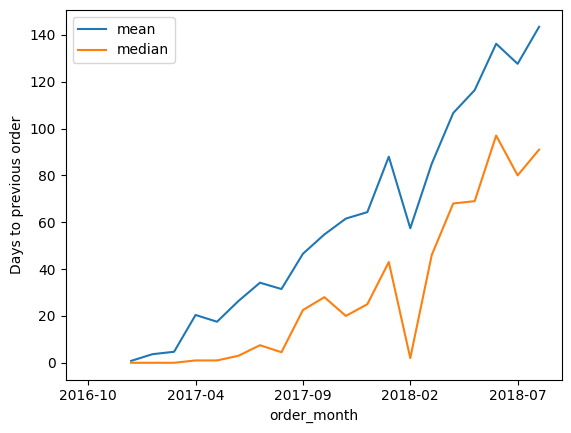

In [12]:
repeat_cust_orders.groupby('order_month')['days_to_prev_order'].agg(['mean', 'median']).plot().set_ylabel('Days to previous order')

## New vs Repeat orders

Now that I have established that the repeat rate is not increasing, I will compare new and repeat orders in terms of value.

From the data, I see that the AOV of repeat orders is 8.4% lower than that of first orders, while the freight value is 1.6% higher.

From this perspective, repeat orders appear slightly less profitable than first orders.

### Note

The dataset does not include Customer Acquisition Cost (CAC), so I cannot draw conclusions about the overall profitability of new vs repeat customers. I can only compare their average order values and delivery costs.

In [13]:
# comparing overall without montly dynamic
orders['is_repeat'] = orders['order_num'] > 1
overall_is_repeat_comparison = orders.groupby('is_repeat').agg({
        'payment_value': 'mean',
        'freight_value': 'mean',
        'order_id': 'count'
    })
display(overall_is_repeat_comparison)
print("Repeat orders average payment is {:.2f}% of First orders".format(overall_is_repeat_comparison['payment_value'][True] / overall_is_repeat_comparison['payment_value'][False] * 100))
print("Repeat orders freight value is {:.2f}% of First orders".format(overall_is_repeat_comparison['freight_value'][True] / overall_is_repeat_comparison['freight_value'][False] * 100))
print("Repeat orders order count is {:.2f}% of First orders".format(overall_is_repeat_comparison['order_id'][True] / overall_is_repeat_comparison['order_id'][False] * 100))

,payment_value,freight_value,order_id
is_repeat,,,
False,160.288531,22.773545,93357
True,146.924811,23.140170,3120


Repeat orders average payment is 91.66% of First orders
Repeat orders freight value is 101.61% of First orders
Repeat orders order count is 3.34% of First orders


## Category analysis

In this section, I compare item categories by their contribution to GMV and their repeat purchase rates.

Since some categories have similar names (for example `home_appliances` and `home_appliances_2`, or several categories starting with `fashion_`), I combine them into broader macro categories. This helps ensure that each category has enough data to calculate repeat rates more reliably.

Note: In this project, categories are combined based on my own logic. In a real-life project, it would be important to consult stakeholders to confirm whether these categories should indeed be grouped together.

The analysis below provides the following insights:

### High GMV categories

Top categories by GMV are naturally low-frequency purchases (Furniture, Electronics, etc.).

### Top repeat categories

High-repeat categories contribute only a small share of total GMV.

### Potential high-repeat categories

The following consumable categories may have potential to contribute more to GMV.

In [14]:
order_items_ds = pd.read_csv('dataset/olist_order_items_dataset.csv')
products_ds = pd.read_csv('dataset/olist_products_dataset.csv')
product_category_name_translation_ds = pd.read_csv('dataset/product_category_name_translation.csv')

In [15]:
# joining all item data into one DataFrame
per_item_data = orders.merge(order_items_ds, on='order_id', how='left') \
    .merge(products_ds[['product_id', 'product_category_name']], on='product_id') \
    .merge(product_category_name_translation_ds[['product_category_name', 'product_category_name_english']], on='product_category_name')
per_item_data

,order_id,customer_id,order_date,payment_value,items_price,freight_value_x,order_num,is_repeat,order_month,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value_y,product_category_name,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,2017-10-02,38.71,29.99,8.72,2,True,2017-10,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,2018-07-24,141.46,118.70,22.76,1,False,2018-07,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-08,179.12,159.90,19.22,1,False,2018-08,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,2017-11-18,72.20,45.00,27.20,1,False,2017-11,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,pet_shop,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-13,28.62,19.90,8.72,1,False,2018-02,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,papelaria,stationery
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108630,63943bddc261676b46f01ca7ac2f7bd8,da62f9e57a76d978d02ab5362c509660,2018-02-06,195.00,174.90,20.10,1,False,2018-02,1,f1d4ce8c6dd66c47bbaa8c6781c2a923,1f9ab4708f3056ede07124aad39a2554,2018-02-12 13:10:37,174.90,20.10,bebes,baby
108631,83c1379a015df1e13d02aae0204711ab,737520a9aad80b3fbbdad19b66b37b30,2017-08-27,271.01,205.99,65.02,1,False,2017-08,1,b80910977a37536adeddd63663f916ad,d50d79cb34e38265a8649c383dcffd48,2017-09-05 15:04:16,205.99,65.02,eletrodomesticos_2,home_appliances_2
108632,11c177c8e97725db2631073c19f07b62,5097a5312c8b157bb7be58ae360ef43c,2018-01-08,441.16,359.98,81.18,1,False,2018-01,1,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,2018-01-12 21:36:21,179.99,40.59,informatica_acessorios,computers_accessories
108633,11c177c8e97725db2631073c19f07b62,5097a5312c8b157bb7be58ae360ef43c,2018-01-08,441.16,359.98,81.18,1,False,2018-01,2,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,2018-01-12 21:36:21,179.99,40.59,informatica_acessorios,computers_accessories


In [16]:
# aggregation by category without dynamic
product_category_agg = per_item_data.groupby(['product_category_name_english'], as_index=False).aggregate({
        'price': 'sum',
        'freight_value_y': 'sum',
        'product_id': 'count',
        'order_id': 'nunique',
        'is_repeat': 'mean'
    }) \
    .rename(columns={
        'product_category_name_english': 'product_category',
        'freight_value_y': 'freight_value',
        'product_id': 'item_count',
        'order_id' : 'order_count',
        'is_repeat': 'repeat_share'
    })

In [17]:
# list of all categories before combining into macro groups
print(product_category_agg['product_category'].sort_values().to_markdown())

|    | product_category                        |
|---:|:----------------------------------------|
|  0 | agro_industry_and_commerce              |
|  1 | air_conditioning                        |
|  2 | art                                     |
|  3 | arts_and_craftmanship                   |
|  4 | audio                                   |
|  5 | auto                                    |
|  6 | baby                                    |
|  7 | bed_bath_table                          |
|  8 | books_general_interest                  |
|  9 | books_imported                          |
| 10 | books_technical                         |
| 11 | cds_dvds_musicals                       |
| 12 | christmas_supplies                      |
| 13 | cine_photo                              |
| 14 | computers                               |
| 15 | computers_accessories                   |
| 16 | consoles_games                          |
| 17 | construction_tools_construction         |
| 18 | construction_

In [18]:
macro_categories = {
    'food': 'Food and Beverages',
    'drinks': 'Food and Beverages',
    'food_drink': 'Food and Beverages',
    'fashio_female_clothing': 'Fashion',
    'fashion_bags_accessories': 'Fashion',
    'fashion_childrens_clothes': 'Fashion',
    'fashion_male_clothing': 'Fashion',
    'fashion_shoes': 'Fashion',
    'fashion_sport': 'Fashion',
    'fashion_underwear_beach': 'Fashion',
    'construction_tools_construction': 'Construction Tools',
    'construction_tools_lights': 'Construction Tools',
    'construction_tools_safety': 'Construction Tools',
    'costruction_tools_garden': 'Construction Tools',
    'costruction_tools_tools': 'Construction Tools',
    'small_appliances': 'Small Appliances',
    'small_appliances_home_oven_and_coffee': 'Small Appliances',
    'furniture_bedroom': 'Furniture',
    'furniture_decor': 'Furniture',
    'furniture_living_room': 'Furniture',
    'furniture_mattress_and_upholstery': 'Furniture',
    'kitchen_dining_laundry_garden_furniture': 'Furniture',
    'bed_bath_table': 'Furniture',
    'office_furniture': 'Furniture',
    'electronics': 'Electronics',
    'cds_dvds_musicals': 'Electronics',
    'computers': 'Electronics',
    'computers_accessories': 'Electronics',
    'consoles_games': 'Electronics',
    'audio': 'Electronics',
    'dvds_blu_ray': 'Electronics',
    'music': 'Electronics',
    'small_appliances': 'Electronics',
    'small_appliances_home_oven_and_coffee': 'Electronics',
    'tablets_printing_image': 'Electronics',
    'books_general_interest': 'Books',
    'books_imported': 'Books',
    'books_technical': 'Books',
    'home_appliances': 'Home Appliances',
    'home_appliances_2': 'Home Appliances',
    'air_conditioning': 'Home Appliances',
    'home_confort': 'Home Comfort',
    'home_comfort_2': 'Home Comfort',
    'baby': 'Baby',
    'diapers_and_hygiene': 'Baby',
}
macro_categories_agg = per_item_data.replace({'product_category_name_english': macro_categories}) \
    .groupby(['product_category_name_english'], as_index=False) \
    .aggregate({
        'price': 'sum',
        'is_repeat': 'mean'
    }) \
    .rename(columns={
        'product_category_name_english': 'product_category',
        'is_repeat': 'repeat_share'
    })
macro_categories_agg['GMV share'] = macro_categories_agg['price'] / total_GMV * 100
macro_categories_agg['Repeat rate'] = macro_categories_agg['repeat_share'] * 100

print(macro_categories_agg.sort_values(['product_category']).to_markdown())

|    | product_category               |            price |   repeat_share |   GMV share |   Repeat rate |
|---:|:-------------------------------|-----------------:|---------------:|------------:|--------------:|
|  0 | Baby                           | 401923           |      0.0274925 |  2.60609    |       2.74925 |
|  1 | Books                          |  68423.2         |      0.0175029 |  0.44366    |       1.75029 |
|  2 | Construction Tools             | 261839           |      0.0334294 |  1.69778    |       3.34294 |
|  3 | Electronics                    |      1.70921e+06 |      0.0298842 | 11.0826     |       2.98842 |
|  4 | Fashion                        | 197339           |      0.0629126 |  1.27955    |       6.29126 |
|  5 | Food and Beverages             |  65203.9         |      0.0566873 |  0.422785   |       5.66873 |
|  6 | Furniture                      |      2.13977e+06 |      0.0480406 | 13.8744     |       4.80406 |
|  7 | Home Appliances                | 240110

<Axes: ylabel='product_category'>

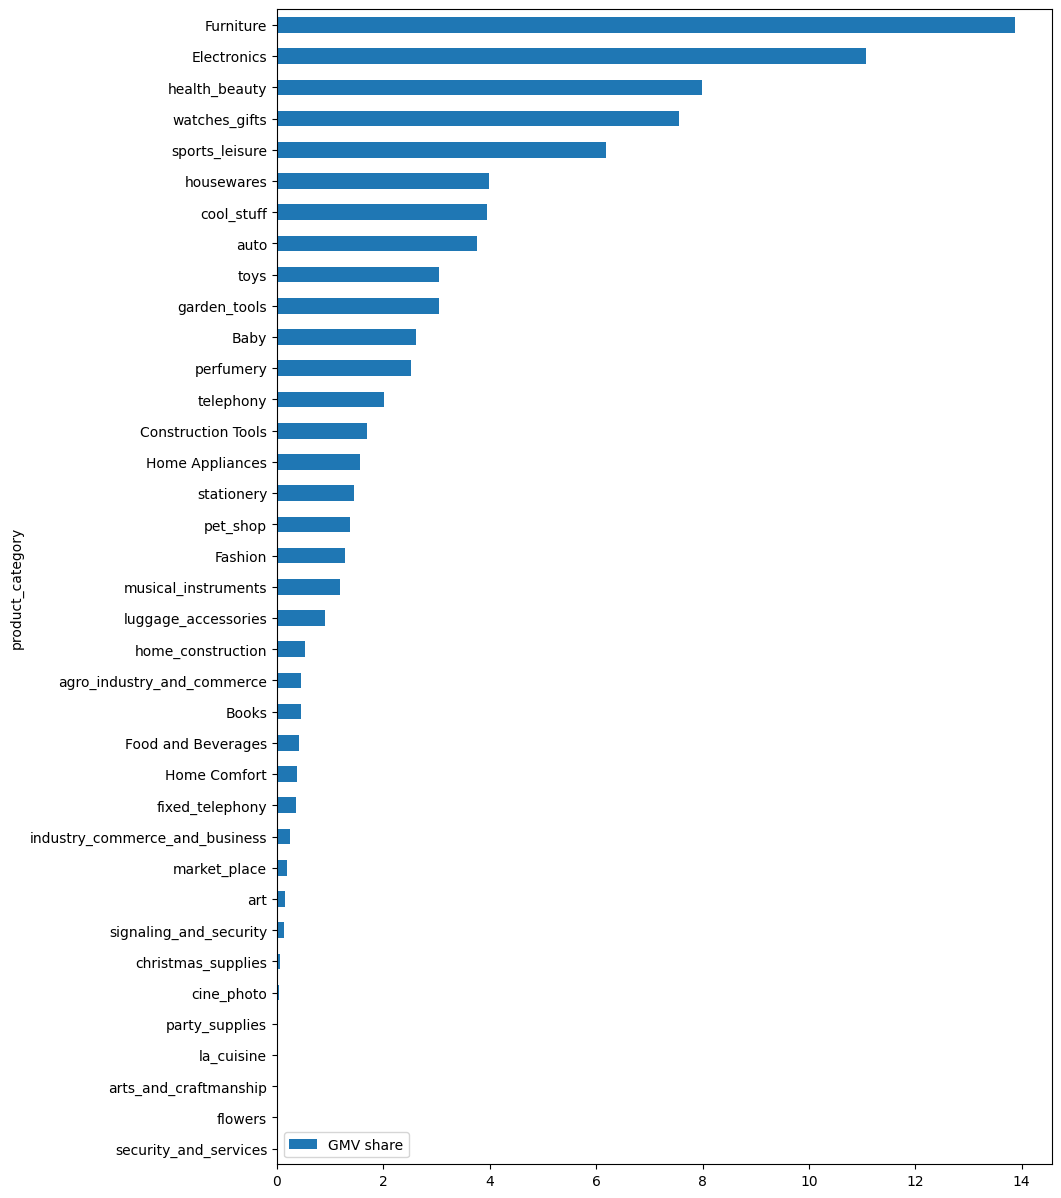

In [19]:
# categories sorted by GMV share (%)
macro_categories_agg.sort_values(['GMV share']).plot.barh(x='product_category', y='GMV share', figsize=(10,15))

<Axes: ylabel='product_category'>

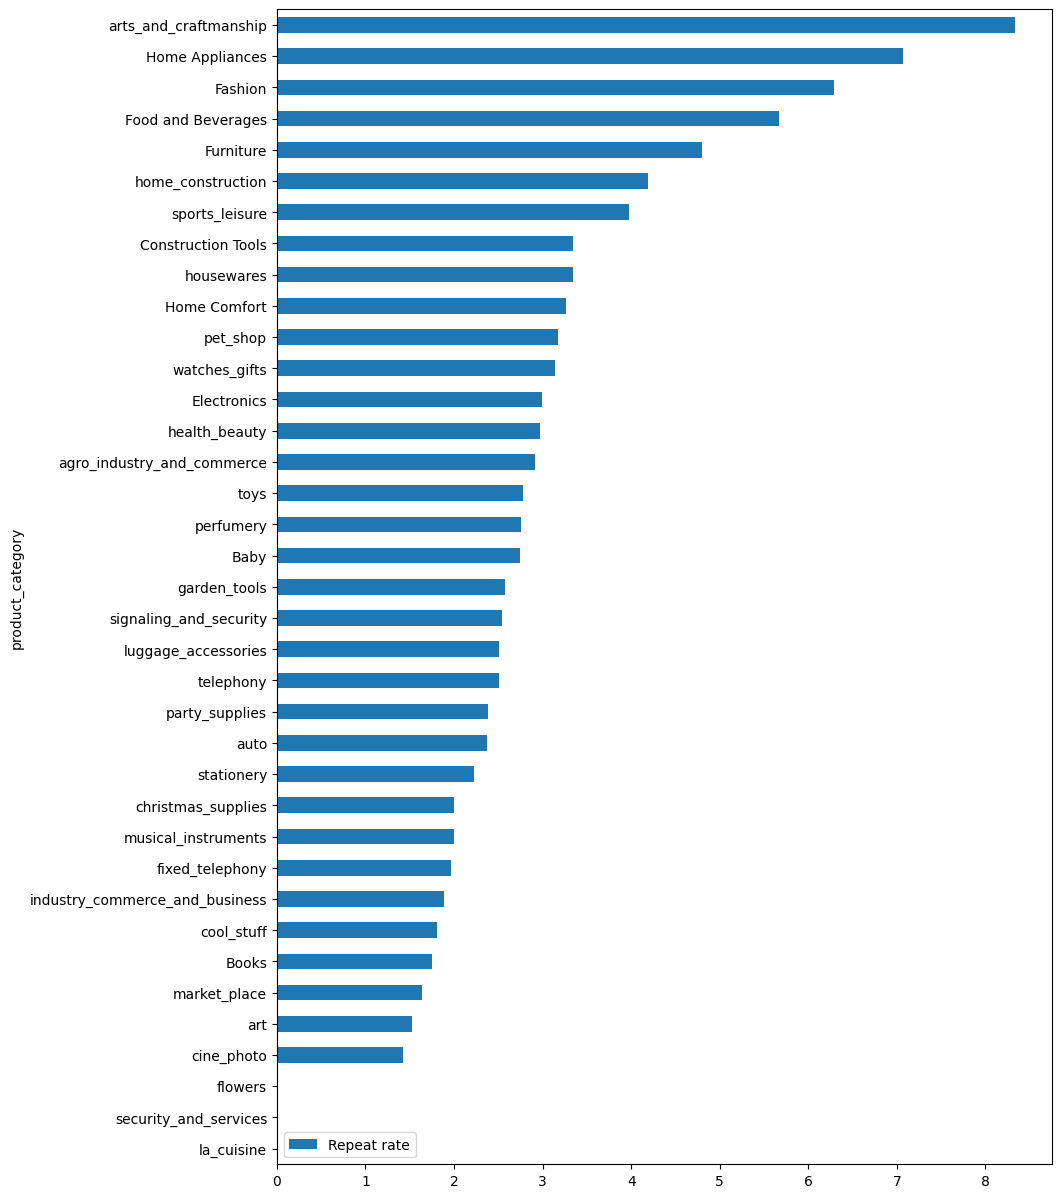

In [20]:
# categories sorted by Repeat rate
macro_categories_agg.sort_values(['Repeat rate']).plot.barh(x='product_category', y='Repeat rate', figsize=(10,15))

<Axes: xlabel='Repeat rate', ylabel='GMV share'>

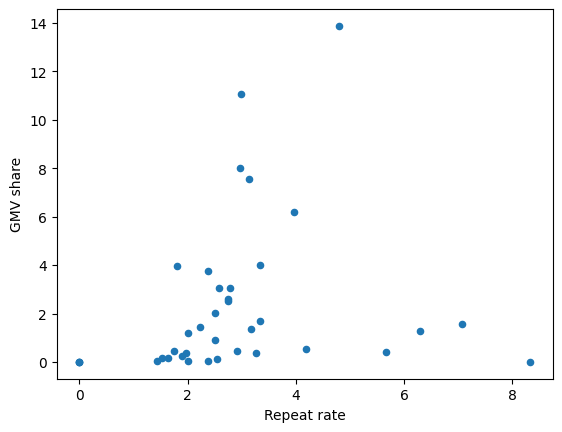

In [21]:
# scatter plot to compare categories GMV share and their Repeat rate
macro_categories_agg.plot.scatter(x='Repeat rate', y='GMV share')

# Exploratory analysis results

## Executive summary

- 97% of customers make only one order
- Repeat order AOV is 8.4% lower than first-order AOV
- Low retention appears to be driven by product mix (durable goods)
- Retention efforts should likely be selective rather than global

## Analysis results

Given the current data, customer acquisition appears to be the primary GMV driver. Improving retention may have a limited impact on GMV. However, evaluating CAC and LTV is required before making strategic decisions.

Targeted retention initiatives could potentially be tested in consumable categories (e.g., Baby, Pet, Toys).

### Limitations & Next Steps

This analysis does not include Customer Acquisition Cost (CAC).

Repeat customers may still be more profitable despite slightly lower AOV if acquisition costs are significant.

Further analysis should incorporate marketing spend data to evaluate true customer lifetime value.